<a href="https://colab.research.google.com/github/fatenmegahed/npro/blob/main/email_classification_using_tf_idf_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

In [77]:
df=pd.read_csv('/content/sms.csv',sep='\t',names=['Status','Message'])

In [78]:
df.head()

,Status,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Status   5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [80]:
df.describe()

,Status,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [81]:
df.shape

(5572, 2)

In [82]:
len(df[df.Status=='spam'])

747

In [83]:
len(df[df.Status=='ham'])

4825

In [84]:
df.Status=df.Status.map({'spam':1,'ham':0})
df.head()

,Status,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


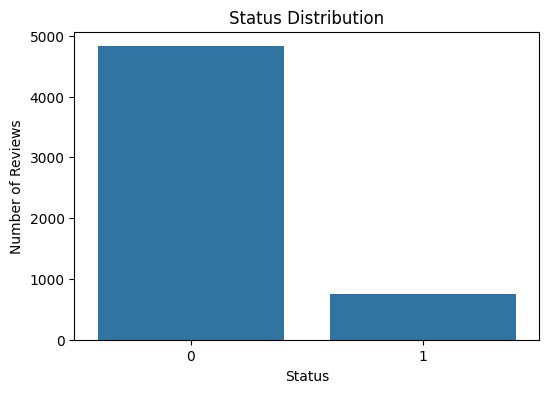

In [85]:

import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Status")

plt.title("Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Reviews")

plt.show()

In [86]:
df_x=df["Message"]
df_y=df["Status"]

In [87]:
cv = TfidfVectorizer(min_df=1,stop_words='english')

In [88]:
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=4)

In [89]:
len(x_test)

1115

In [90]:
x_train.head()

,Message
1457,U sleeping now.. Or you going to take? Haha.. ...
472,"How long has it been since you screamed, princ..."
2481,Urgent! call 09066612661 from landline. Your c...
243,"Okay. No no, just shining on. That was meant t..."
1413,"Wen ur lovable bcums angry wid u, dnt take it ..."


In [91]:
x_traincv=cv.fit_transform(x_train)
a=x_traincv.toarray()
a[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [92]:
x_testcv=cv.transform(x_test)
x_testcv.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [93]:
mnb = MultinomialNB()

In [94]:
y_train=y_train.astype('int')
y_train

,Status
1457,0
472,0
2481,1
243,0
1413,0
...,...
3671,0
709,1
2487,0
174,0


In [95]:
model=mnb.fit(x_traincv,y_train)

In [96]:
predictions=model.predict(x_testcv)
predictions

array([0, 0, 0, ..., 0, 0, 1])

In [97]:
a=np.array(y_test)
a

array([0, 0, 0, ..., 0, 0, 1])

In [98]:
count=0    #true prediction
for i in range (len(predictions)):
    if predictions[i]==a[i]:
        count=count+1
count

1068

In [99]:
len(predictions)

1115

In [100]:
accuracy=count/len(predictions)
accuracy

0.957847533632287

In [101]:
accuracy_score(y_test,predictions)

0.957847533632287

In [102]:
import joblib


In [103]:

joblib.dump(model,'spam_ham_model.pkl')
joblib.dump(cv,'cv.pkl')


['cv.pkl']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')